<a href="https://colab.research.google.com/github/nouval0425/Learning-Python/blob/main/Citra_Digital_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
uploaded = files.upload()

# Ambil nama file
image_paths = list(uploaded.keys())

# Baca gambar
images = [cv2.imread(path) for path in image_paths]

# Convert BGR ke RGB
images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in images]

Saving horse.jpg to horse.jpg


In [7]:
def show_image(title, img):
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

def show_histogram(img, title):
    plt.hist(img.ravel(), bins=256, range=[0,256])
    plt.title(title)
    plt.show()

Brightness

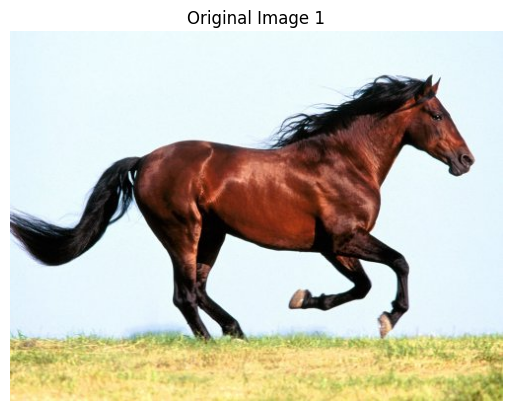

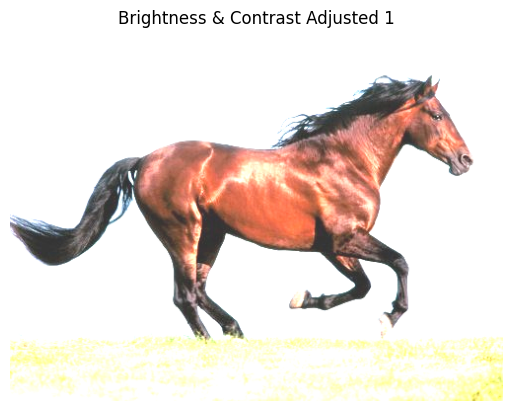

In [8]:
def adjust_brightness_contrast(img, alpha=1.5, beta=50):
    # alpha = contrast, beta = brightness
    new_img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
    return new_img

for i, img in enumerate(images):
    result = adjust_brightness_contrast(img)

    show_image(f"Original Image {i+1}", img)
    show_image(f"Brightness & Contrast Adjusted {i+1}", result)

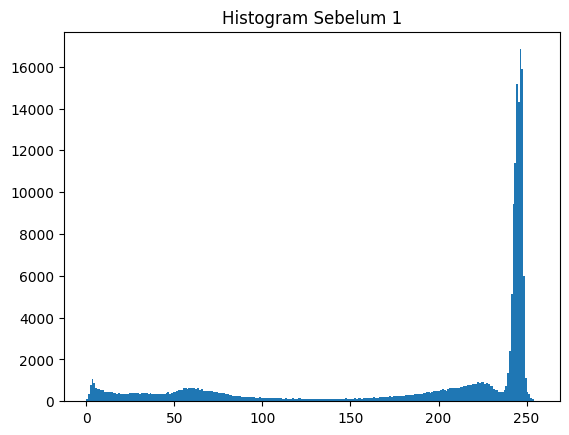

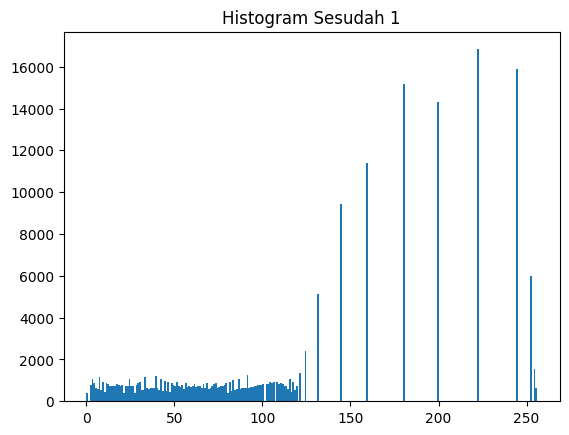

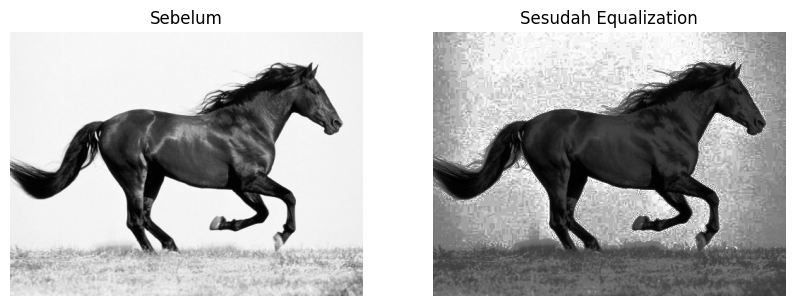

In [9]:
for i, img in enumerate(images):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Histogram sebelum
    show_histogram(gray, f"Histogram Sebelum {i+1}")

    # Equalization
    equalized = cv2.equalizeHist(gray)

    # Histogram sesudah
    show_histogram(equalized, f"Histogram Sesudah {i+1}")

    # Tampilkan hasil
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(gray, cmap='gray')
    plt.title("Sebelum")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(equalized, cmap='gray')
    plt.title("Sesudah Equalization")
    plt.axis('off')
    plt.show()

sharpening

In [10]:
def laplacian_sharpen(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    sharpened = cv2.convertScaleAbs(gray - laplacian)
    return sharpened

In [11]:
def unsharp_mask(img):
    gaussian = cv2.GaussianBlur(img, (9,9), 10.0)
    sharpened = cv2.addWeighted(img, 1.5, gaussian, -0.5, 0)
    return sharpened

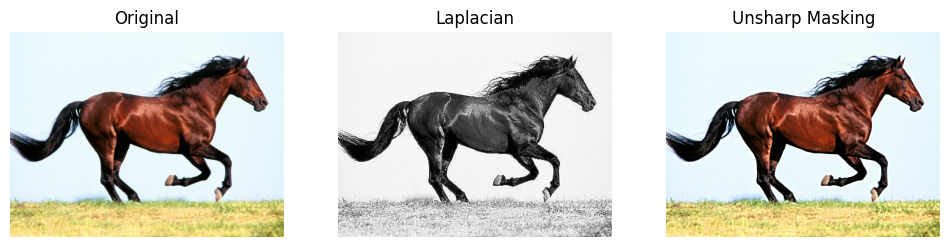

In [12]:
for i, img in enumerate(images):
    lap = laplacian_sharpen(img)
    unsharp = unsharp_mask(img)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(lap, cmap='gray')
    plt.title("Laplacian")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(unsharp)
    plt.title("Unsharp Masking")
    plt.axis('off')

    plt.show()